In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [12]:
df = pd.read_csv('../data/Wholesale customers data.csv')
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
scaler = StandardScaler()

In [17]:
X_scaled = scaler.fit_transform(df)

In [18]:
X_scaled

array([[ 1.44865163,  0.59066829,  0.05293319, ..., -0.58936716,
        -0.04356873, -0.06633906],
       [ 1.44865163,  0.59066829, -0.39130197, ..., -0.27013618,
         0.08640684,  0.08915105],
       [ 1.44865163,  0.59066829, -0.44702926, ..., -0.13753572,
         0.13323164,  2.24329255],
       ...,
       [ 1.44865163,  0.59066829,  0.20032554, ..., -0.54337975,
         2.51121768,  0.12145607],
       [-0.69029709,  0.59066829, -0.13538389, ..., -0.41944059,
        -0.56977032,  0.21304614],
       [-0.69029709,  0.59066829, -0.72930698, ..., -0.62009417,
        -0.50488752, -0.52286938]], shape=(440, 8))

In [19]:
pca = PCA(n_components=2)
X_scaled_pca = pca.fit_transform(X_scaled)
X_scaled_pca

array([[ 8.43938928e-01, -5.15350749e-01],
       [ 1.06267645e+00, -4.84601258e-01],
       [ 1.26914052e+00,  6.82054553e-01],
       [-1.05678239e+00,  6.10821496e-01],
       [ 6.34030484e-01,  9.74198836e-01],
       [ 5.30110898e-01, -5.85411382e-01],
       [ 3.99560245e-01, -8.46342878e-01],
       [ 7.91165650e-01, -4.61140175e-01],
       [-6.63831131e-01, -5.77465454e-01],
       [ 2.15068480e+00, -6.17913981e-01],
       [ 1.25599389e+00, -5.12452434e-01],
       [-1.68210612e-01, -6.88796117e-01],
       [ 1.43985588e+00,  6.08852947e-01],
       [ 1.40695611e+00, -1.60564663e-01],
       [ 1.37395999e+00,  6.85013841e-02],
       [-1.07181521e+00, -5.19859188e-01],
       [ 1.25801233e+00, -1.12165441e+00],
       [-6.18599013e-01,  2.82406711e-01],
       [ 8.67093429e-01,  2.20448419e-01],
       [-4.84666795e-01, -5.76463994e-01],
       [ 3.31514687e-01, -1.94171620e-01],
       [-1.25444108e+00, -3.05734448e-01],
       [-6.95754707e-01,  2.16418147e+00],
       [ 4.

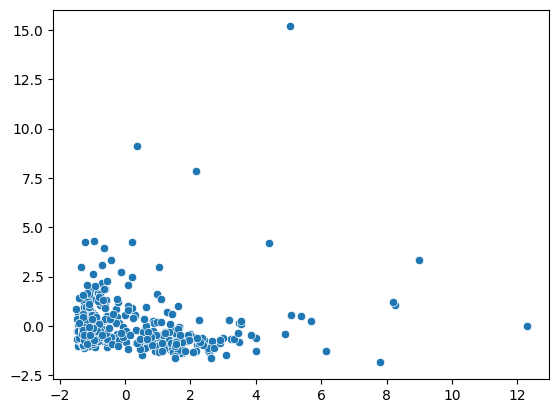

In [20]:
sns.scatterplot(x=X_scaled_pca[:, 0], y=X_scaled_pca[:, 1])
plt.show()

In [21]:
inertia = []
K = range(1, 11)

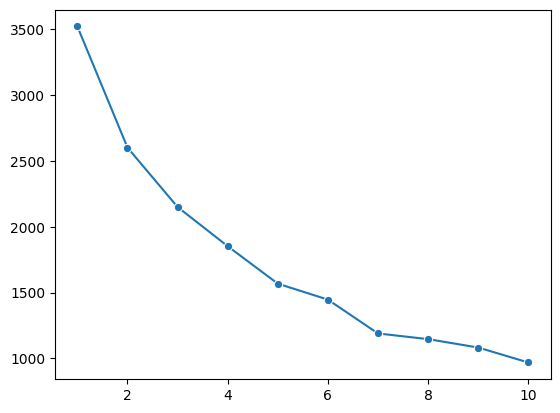

In [23]:
for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    model.fit(X_scaled)
    inertia.append(model.inertia_)
    
sns.lineplot(x=K, y=inertia, marker='o')
plt.show()

## Попробуем без `Channel` и `Region`

In [24]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [25]:
df_changed = df.drop(['Channel', 'Region'], axis=1)
df_changed.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [26]:
X_scaled = scaler.fit_transform(df_changed)
X_scaled

array([[ 0.05293319,  0.52356777, -0.04111489, -0.58936716, -0.04356873,
        -0.06633906],
       [-0.39130197,  0.54445767,  0.17031835, -0.27013618,  0.08640684,
         0.08915105],
       [-0.44702926,  0.40853771, -0.0281571 , -0.13753572,  0.13323164,
         2.24329255],
       ...,
       [ 0.20032554,  1.31467078,  2.34838631, -0.54337975,  2.51121768,
         0.12145607],
       [-0.13538389, -0.51753572, -0.60251388, -0.41944059, -0.56977032,
         0.21304614],
       [-0.72930698, -0.5559243 , -0.57322717, -0.62009417, -0.50488752,
        -0.52286938]], shape=(440, 6))

In [27]:
X_scaled_pca = pca.fit_transform(X_scaled)
X_scaled_pca

array([[ 1.93290546e-01, -3.05099963e-01],
       [ 4.34419896e-01, -3.28412623e-01],
       [ 8.11143234e-01,  8.15095701e-01],
       [-7.78647832e-01,  6.52753734e-01],
       [ 1.66287259e-01,  1.27143372e+00],
       [-1.56169932e-01, -2.95140988e-01],
       [-3.35288404e-01, -5.25003258e-01],
       [ 1.40586434e-01, -2.30992687e-01],
       [-5.17319541e-01, -6.59362827e-01],
       [ 1.59210908e+00, -7.41011332e-01],
       [ 6.38085945e-01, -4.01825201e-01],
       [-9.27692579e-01, -2.19287242e-01],
       [ 9.91362176e-01,  6.85910808e-01],
       [ 8.50246760e-01, -8.56919642e-02],
       [ 8.45043794e-01,  1.54724325e-01],
       [-9.51585375e-01, -4.95908498e-01],
       [ 5.57558717e-01, -1.02612272e+00],
       [-3.52538598e-01,  2.07075910e-01],
       [ 3.16578563e-01,  4.42066292e-01],
       [-3.23755737e-01, -7.03586946e-01],
       [-3.20000597e-01,  1.56628147e-01],
       [-1.11844720e+00, -2.30527519e-01],
       [-1.76694545e-01,  2.14371699e+00],
       [ 4.

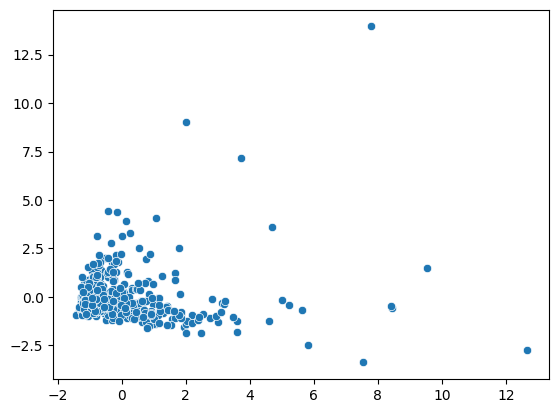

In [28]:
sns.scatterplot(x=X_scaled_pca[:, 0], y=X_scaled_pca[:, 1])
plt.show()

In [29]:
inertia = []
K = range(1, 11)

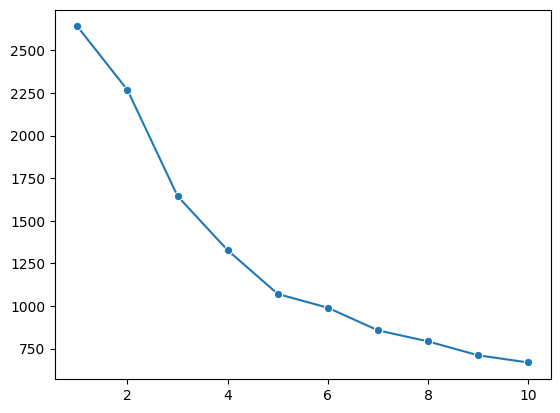

In [31]:
for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42
    )
    model.fit(X_scaled)
    inertia.append(model.inertia_)
    
sns.lineplot(x=K, y=inertia, marker='o')
plt.show()

## Попробуем сделать логарифмирование, чтобы снизить влияние выбросов

In [32]:
df_changed.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


In [33]:
X_changed_log = np.log1p(df_changed)

In [34]:
X_changed_log

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,8.756840,9.083529,8.947026,7.785721,8.165364,8.967632
3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,10.026413,8.596189,8.881697,8.272826,7.483244,8.553718
...,...,...,...,...,...,...
435,10.299037,9.396986,9.682092,9.483112,5.209486,7.698483
436,10.577172,7.266827,6.639876,8.414274,4.543295,7.760893
437,9.584108,9.647885,10.317053,6.082219,9.605216,7.532624
438,9.239025,7.591862,7.711101,6.946014,5.129899,7.661998


In [35]:
X_changed_log_scaled = scaler.fit_transform(X_changed_log)
X_changed_log_scaled

array([[ 0.4861845 ,  0.97629884,  0.44015468, -1.50924981,  0.64414327,
         0.40896595],
       [ 0.08788863,  0.99095612,  0.65217085,  0.13405226,  0.76604314,
         0.62792606],
       [ 0.01635628,  0.89115098,  0.45468702,  0.37689926,  0.80440496,
         1.77683339],
       ...,
       [ 0.57952767,  1.41399051,  1.68865731, -0.95351417,  1.64761948,
         0.66656608],
       [ 0.34460869, -0.49078257, -0.65849797, -0.27890118, -0.97324089,
         0.76666284],
       [-0.54442663, -0.63351532, -0.55281539, -2.43158276, -0.36435895,
        -2.0896139 ]], shape=(440, 6))

In [36]:
X_changed_log_scaled_pca = pca.fit_transform(X_changed_log_scaled)
X_changed_log_scaled_pca

array([[ 1.38038279e+00, -3.04726833e-01],
       [ 1.43886964e+00,  5.37468226e-01],
       [ 1.51345256e+00,  1.23256453e+00],
       [-8.25105399e-01,  1.21078962e+00],
       [ 8.02897108e-01,  1.76604596e+00],
       [ 8.86165465e-01,  1.29894179e-01],
       [ 6.03256020e-01, -4.61548124e-01],
       [ 1.15264871e+00,  6.07676153e-01],
       [ 5.30012066e-01, -6.30138062e-01],
       [ 2.19686557e+00,  3.26049510e-01],
       [ 1.43963779e+00,  5.54203107e-01],
       [-8.44476818e-01, -2.20841715e-02],
       [ 1.88285588e+00,  5.32338198e-01],
       [ 1.35028903e+00,  7.07840715e-01],
       [ 1.81571213e+00,  2.75000938e-01],
       [-6.30635468e-01, -8.08456441e-01],
       [ 1.94097238e+00, -1.65430313e+00],
       [ 1.38588659e-01,  5.40841151e-01],
       [ 1.19332956e+00,  1.22204216e+00],
       [ 5.46470299e-01, -5.44713456e-01],
       [ 5.69829905e-01,  6.69507283e-01],
       [-1.52192160e+00,  7.62767889e-02],
       [-1.65729348e-02,  2.08924555e+00],
       [ 2.

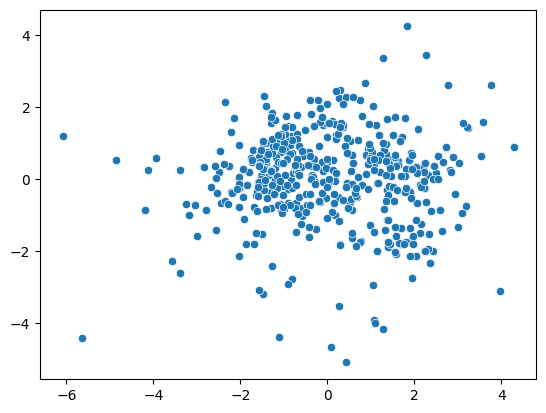

In [37]:
sns.scatterplot(x=X_changed_log_scaled_pca[:, 0], y=X_changed_log_scaled_pca[:, 1])
plt.show()

In [39]:
inertia = []
K = range(1, 11)

In [40]:
for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    model.fit(X_changed_log_scaled)
    inertia.append(model.inertia_)

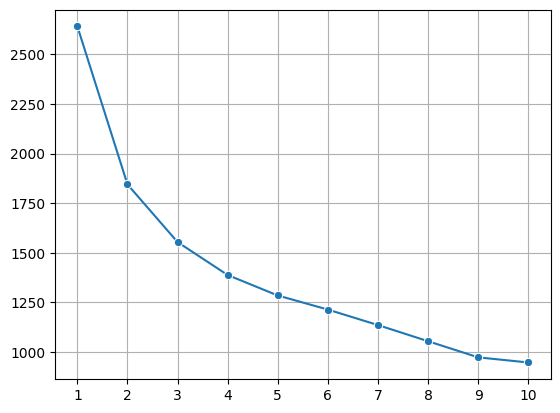

In [47]:
sns.lineplot(x=K, y=inertia, marker='o')
plt.xticks(K)
plt.grid()
plt.show()

### Попробуем добавить метрик

In [56]:
inertia = []
K = range(1, 11)

In [57]:
for k in K:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_changed_log_scaled)
    inertia.append(model.inertia_)

    n_labels = len(np.unique(labels))

    if n_labels < 2:
        print(
            f'При k={k}:\n'
            f'\tsilhouette_score=ND;\n'
            f'\tcalinski_harabasz_score=ND;\n'
            f'\tdavies_bouldin_score=ND'
        )
    else:
        print(
            f'При k={k}:\n'
            f'\tsilhouette_score={silhouette_score(X_changed_log_scaled, labels)};\n'
            f'\tcalinski_harabasz_score={calinski_harabasz_score(X_changed_log_scaled, labels)}\n'
            f'\tdavies_bouldin_score={davies_bouldin_score(X_changed_log_scaled, labels)}'
        )

    print('-----------------------------------')

При k=1:
	silhouette_score=ND;
	calinski_harabasz_score=ND;
	davies_bouldin_score=ND
-----------------------------------
При k=2:
	silhouette_score=0.2903284869973543;
	calinski_harabasz_score=189.04979701772055
	davies_bouldin_score=1.351501586224928
-----------------------------------
При k=3:
	silhouette_score=0.25941565559741453;
	calinski_harabasz_score=152.8351876500921
	davies_bouldin_score=1.3405631342807725
-----------------------------------
При k=4:
	silhouette_score=0.1884954525130424;
	calinski_harabasz_score=131.31985558639303
	davies_bouldin_score=1.5407719614906932
-----------------------------------
При k=5:
	silhouette_score=0.1915850843191521;
	calinski_harabasz_score=118.00049937217794
	davies_bouldin_score=1.4842792859594358
-----------------------------------
При k=6:
	silhouette_score=0.20088699307469401;
	calinski_harabasz_score=108.2630483155232
	davies_bouldin_score=1.432345724934278
-----------------------------------
При k=7:
	silhouette_score=0.195779732803

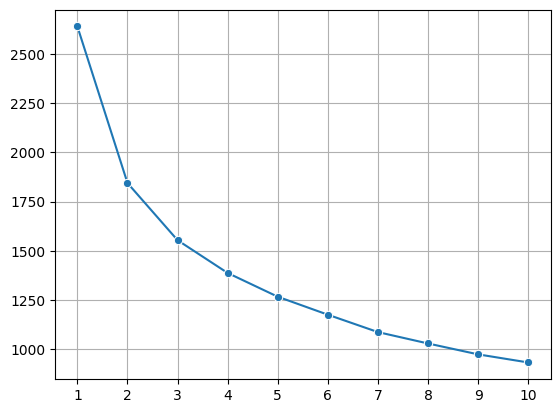

In [58]:
sns.lineplot(x=K, y=inertia, marker='o')
plt.xticks(K)
plt.grid()
plt.show()

### Метрики `silhouette_score` и `calinski_harabasz_score` показали, что на разделении на 2 кластера результаты лучше остальных.

In [59]:
model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels = model.fit_predict(X_changed_log_scaled)

In [60]:
X_changed_log_scaled

array([[ 0.4861845 ,  0.97629884,  0.44015468, -1.50924981,  0.64414327,
         0.40896595],
       [ 0.08788863,  0.99095612,  0.65217085,  0.13405226,  0.76604314,
         0.62792606],
       [ 0.01635628,  0.89115098,  0.45468702,  0.37689926,  0.80440496,
         1.77683339],
       ...,
       [ 0.57952767,  1.41399051,  1.68865731, -0.95351417,  1.64761948,
         0.66656608],
       [ 0.34460869, -0.49078257, -0.65849797, -0.27890118, -0.97324089,
         0.76666284],
       [-0.54442663, -0.63351532, -0.55281539, -2.43158276, -0.36435895,
        -2.0896139 ]], shape=(440, 6))

In [64]:
df_target = pd.DataFrame(
    X_changed_log_scaled_pca,
    columns=['f1', 'f2',]
)

df_target['target'] = labels
df_target.head()

,f1,f2,target
0,1.380383,-0.304727,1
1,1.438870,0.537468,1
2,1.513453,1.232565,1
3,-0.825105,1.210790,0
4,0.802897,1.766046,1


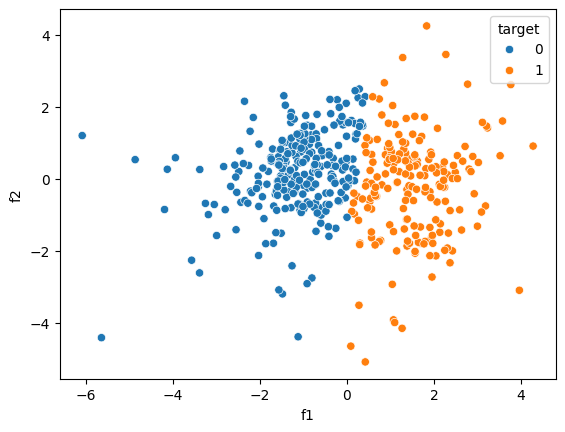

In [66]:
sns.scatterplot(data=df_target, x='f1', y='f2', hue='target')
plt.show()

## Вывод

В ходе работы с датасетом *Wholesale customers data* были выполнены несколько этапов предварительной обработки данных. Сначала были проанализированы исходные признаки, после чего из набора были исключены категориальные переменные `Channel` и `Region`, так как основное внимание уделялось кластеризации по числовым характеристикам покупательского поведения.

Для повышения качества разбиения данных были применены стандартизация и логарифмирование признаков. Эти преобразования позволили снизить влияние выбросов, уменьшить перекос распределений и сделать структуру данных более пригодной для кластеризации. После этого был построен график метода локтя, по которому можно было рассматривать несколько возможных вариантов числа кластеров, в частности `k = 2` и `k = 3`.

Чтобы выбрать оптимальное число кластеров, дополнительно были рассчитаны метрики качества кластеризации: `silhouette_score`, `calinski_harabasz_score` и `davies_bouldin_score`. Результаты показали, что по первым двум метрикам наилучшее качество достигается при `k = 2`. Метрика `Davies-Bouldin` в некоторых случаях немного лучше оценивала вариант с тремя кластерами, однако различия оказались несущественными.

Таким образом, с учетом визуального анализа, метода локтя и значений метрик качества было принято решение остановиться на **2 кластерах** как на наиболее обоснованном варианте разбиения данных.